# 05 · Sensory track: which cupping dimensions define excellence?

The second track switches from farm-level variables to the scores assigned by the Q-grader panel (aroma, flavour, aftertaste, acidity, body, balance…). Two things must be said before any model is fitted:

* these scores are only available **after** cupping, so nothing here helps *predict* excellence early;
* they are the **components of the target**: `Total.Cup.Points` is their sum (plus uniformity, clean cup, sweetness and cupper points). A classifier trained on them is not predicting quality, it is partially *reconstructing* the definition of quality. Any accuracy it reaches is target leakage by construction.

Why keep the track at all? Because the *relative* weight of the dimensions is still a legitimate question for cuppers and producers: given that a lot is excellent, which sensory attribute is doing the work?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coffee_quality import config as C
from coffee_quality import data, eda, plotting as P

P.set_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
from coffee_quality import evaluation as E, sensory as S

df = data.load_clean()
mw = eda.mann_whitney_by_class(df, C.SENSORY_COLS[:-1])
mw.round(4)

,feature,median_not_excellent,median_excellent,mean_difference,p_value
0,Flavor,7.50,8.08,0.6437,0.0000
1,Aftertaste,7.42,7.92,0.6116,0.0000
2,Acidity,7.50,8.08,0.5882,0.0000
3,Aroma,7.58,8.00,0.5279,0.0000
4,Balance,7.50,8.00,0.5382,0.0000
5,Body,7.50,7.92,0.4656,0.0000
6,Clean.Cup,10.00,10.00,0.1653,0.0072
7,Uniformity,10.00,10.00,0.1314,0.0087
8,Sweetness,10.00,10.00,0.0626,0.3170


Every dimension differs between classes (unsurprisingly — they add up to the score). `Uniformity`, `Clean.Cup` and `Sweetness` are near-constant at 10/10 for almost every lot and are dropped; `Cupper.Points` is a global judgement rather than a sensory attribute and is dropped too. Six dimensions remain.

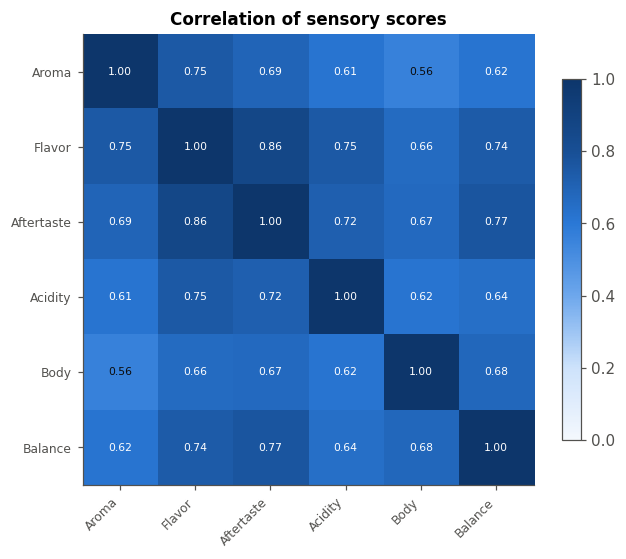

In [2]:
X, y = S.sensory_matrix(df)
P.plot_corr_heatmap(X.corr(), "Correlation of sensory scores");

Pairwise correlations between 0.56 and 0.86: the panel scores move together (a "halo" effect plus genuine quality). Coefficients of a linear model will therefore be unstable individually; that is why the ranking below combines four different importance measures.

## 1. Models

In [3]:
X_train, X_test, y_train, y_test = data.stratified_split(X, y, test_size=0.25)
models = {"Logistic regression": S.build_logistic(), "Random forest": S.build_random_forest_grid()}
S.cross_validated_scores(models, X_train, y_train).round(3)

mean                               std              
model             Logistic regression Random forest Logistic regression Random forest
metric                                                                               
average_precision               0.939         0.912               0.047         0.060
balanced_accuracy               0.977         0.933               0.019         0.018
f1                              0.844         0.817               0.067         0.064
roc_auc                         0.995         0.990               0.004         0.006

In [4]:
rows, fitted = [], {}
for name, model in models.items():
    fitted[name] = model.fit(X_train, y_train)
    proba = fitted[name].predict_proba(X_test)[:, 1]
    rows.append({"model": name, **E.compute_metrics(y_test, proba, 0.5)})
pd.DataFrame(rows).set_index("model").round(3)

,precision,recall,f1,balanced_accuracy,roc_auc,auprc
model,,,,,,
Logistic regression,0.722,1.000,0.839,0.982,0.996,0.934
Random forest,0.857,0.923,0.889,0.954,0.994,0.904


ROC AUC ≈ 0.99, AUPRC ≈ 0.9: spectacular, and meaningless as *prediction* — this is the sensory paradox. Compare with AUPRC ≈ 0.4 for the agronomic models of notebook 03, which are the only ones that could actually be used before tasting.

## 2. Which dimensions matter most?

In [5]:
logit, logit_table = S.fit_logit_statsmodels(X_train, y_train)
logit_table.round(4)

,coef,std_err,p_value,odds_ratio_per_sd
Aroma,1.3817,0.4621,0.0028,3.9818
Flavor,2.2511,0.7656,0.0033,9.4979
Aftertaste,2.3928,0.7065,0.0007,10.9438
Acidity,1.6925,0.4803,0.0004,5.4333
Body,1.3824,0.4500,0.0021,3.9844
Balance,1.6591,0.4624,0.0003,5.2546


,feature,logit_coef,lasso_coef,permutation_importance,rf_gini_importance,mean_difference,overall_score
0,Flavor,2.251,4.666,0.165,0.307,0.644,0.965
1,Aftertaste,2.393,3.066,0.078,0.169,0.612,0.541
2,Balance,1.659,2.611,0.161,0.224,0.538,0.522
3,Acidity,1.693,2.515,0.099,0.152,0.588,0.335
4,Body,1.382,2.416,0.046,0.071,0.466,0.067
5,Aroma,1.382,2.110,0.025,0.076,0.528,0.005


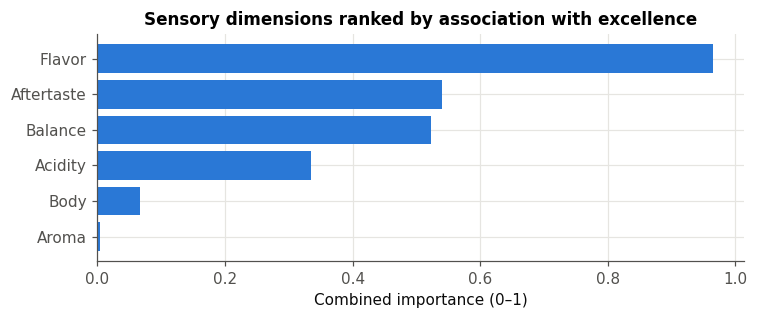

In [6]:
lasso = S.lasso_path_coefficients(X_train, y_train)
rf_best = getattr(fitted["Random forest"], "best_estimator_", fitted["Random forest"])
gini = pd.Series(rf_best.feature_importances_, index=X.columns)
perm = S.oof_permutation_importance(models["Random forest"], X_train, y_train, n_repeats=10)
ranking = S.final_ranking(logit_table, lasso, gini, perm, mw.set_index("feature")["mean_difference"])
P.plot_importance(ranking.rename(columns={"overall_score": "score"}), "score", "Combined importance (0–1)", "Sensory dimensions ranked by association with excellence");
ranking.round(3)

**Flavour** leads three of the four measures (largest lasso coefficient, Gini and permutation importance) and is second only to aftertaste in the unpenalised logit; **aftertaste**, **balance** and **acidity** form a second tier; **body** and **aroma** contribute least once the others are known. The top and the bottom of the ordering are stable across methods, which matters given the collinearity; the middle tier is not, and should be read as a tie.

## Conclusion of the two tracks

| | Agronomic model | Sensory model |
|---|---|---|
| available | before harvest / before cupping | after cupping |
| test AUPRC | ≈ 0.4 (random: 0.08) | ≈ 0.9 |
| what it tells us | altitude, defects, moisture, origin and processing carry a real but weak signal | flavour and aftertaste are the dimensions that make a coffee *excellent* |
| main risk | small, noisy positives; hidden lab artefacts (moisture = 0) | target leakage: the predictors define the target |

Predicting elite coffee before anyone tastes it is possible only in a screening sense. The cup still decides.